In [220]:
import numpy as np
import random
import geopandas as gpd
import contextily as ctx
import osmnx as ox
import h3
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Polygon, Point, mapping, MultiPolygon
from shapely.strtree import STRtree
from math import pi, cos, sin, exp, sqrt, radians, atan2
from geopy.distance import geodesic

# **US DATA**

In [161]:
bbox_dict = {
    'chicago': {'lat_min': 41.0, 'lat_max': 43.5, 'lon_min': -90.0, 'lon_max': -86.0},
    'la': {'lat_min': 33.0, 'lat_max': 35.5, 'lon_min': -121.0, 'lon_max': -115.0},
    'boston': {'lat_min': 41.0, 'lat_max': 43.0, 'lon_min': -72.75, 'lon_max': -69.75},
    'austin': {'lat_min': 29.0, 'lat_max': 32.0, 'lon_min': -99.0, 'lon_max': -96.0},
    'nyc': {'lat_min': 40.39, 'lat_max': 41.44, 'lon_min': -74.69, 'lon_max': -72.12}
}

In [162]:
tracts = gpd.read_file("../data/US Tracts SHP/US_tract_2023.shp")[['GISJOIN', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area', 'ORIG_FID', 'geometry']]

if tracts.crs is None or tracts.crs.to_string() != "EPSG:4326":
    tracts = tracts.to_crs(epsg=4326)

In [163]:
# Function to filter by bbox using centroid
def filter_bbox(gdf, bbox):
    centroids = gdf.geometry.centroid
    mask = (
        (centroids.y >= bbox['lat_min']) &
        (centroids.y <= bbox['lat_max']) &
        (centroids.x >= bbox['lon_min']) &
        (centroids.x <= bbox['lon_max'])
    )
    return gdf[mask]


In [164]:
gdf_chicago = filter_bbox(tracts, bbox_dict['chicago'])
gdf_la = filter_bbox(tracts, bbox_dict['la'])
gdf_boston = filter_bbox(tracts, bbox_dict['boston'])
gdf_austin = filter_bbox(tracts, bbox_dict['austin'])
gdf_nyc = filter_bbox(tracts, bbox_dict['nyc'])

/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2965/1778288636.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2965/1778288636.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2965/1778288636.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid
/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2965/1778288636.py:3: UserWarning: 

In [145]:
gdf_chicago

,GISJOIN,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,ORIG_FID,geometry
24938,G1700070010101,17,007,010101,17007010101,1400000US17007010101,101.01,Census Tract 101.01,G5020,S,+42.2699643,-088.8428009,11640.198849,4.968274e+06,41779,"POLYGON ((-88.82203 42.26036, -88.82233 42.260..."
24939,G1700070010102,17,007,010102,17007010102,1400000US17007010102,101.02,Census Tract 101.02,G5020,S,+42.2641730,-088.8711066,12328.284090,4.403400e+06,41778,"POLYGON ((-88.84098 42.2602, -88.84159 42.2598..."
24940,G1700070010200,17,007,010200,17007010200,1400000US17007010200,102,Census Tract 102,G5020,S,+42.2487471,-088.8324850,13805.279143,5.367349e+06,41325,"POLYGON ((-88.82203 42.26036, -88.82204 42.260..."
24941,G1700070010300,17,007,010300,17007010300,1400000US17007010300,103,Census Tract 103,G5020,S,+42.2435995,-088.8528182,8370.848184,3.911699e+06,41366,"POLYGON ((-88.84175 42.23368, -88.84659 42.233..."
24942,G1700070010400,17,007,010400,17007010400,1400000US17007010400,104,Census Tract 104,G5020,S,+42.2035845,-088.8275388,73259.178421,2.175922e+08,41322,"POLYGON ((-88.88588 42.26997, -88.88581 42.269..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83888,G5501330204302,55,133,204302,55133204302,1400000US55133204302,2043.02,Census Tract 2043.02,G5020,S,+43.0927755,-088.4836846,11070.162508,6.325335e+06,52830,"POLYGON ((-88.4705 43.10504, -88.47055 43.1047..."
83889,G5501330204400,55,133,204400,55133204400,1400000US55133204400,2044,Census Tract 2044,G5020,S,+43.1424222,-088.5214037,14022.945625,1.120141e+07,53095,"POLYGON ((-88.49975 43.14324, -88.49974 43.141..."
83890,G5501330204501,55,133,204501,55133204501,1400000US55133204501,2045.01,Census Tract 2045.01,G5020,S,+43.1700863,-088.4700526,34085.138476,6.253414e+07,53399,"POLYGON ((-88.4009 43.14214, -88.40097 43.1421..."
83891,G5501330204503,55,133,204503,55133204503,1400000US55133204503,2045.03,Census Tract 2045.03,G5020,S,+43.1191648,-088.4373870,12675.747386,8.052724e+06,52735,"POLYGON ((-88.42188 43.10358, -88.42192 43.103..."


In [165]:
demographics_df = pd.read_csv("../data/US_census/nhgis0003_ds267_20235_tract.csv")

columns_rename = {
    # Geographic data (tract identifiers)
    'GISJOIN': 'GISJOIN',
    'GEO_ID': 'geo_id',
    'STATE': 'state',
    'TRACTA': 'tract',
    'NAME_E': 'area_name',
    'INTPTLAT': 'lat',
    'INTPTLON': 'lon',    

    # Total population
    'ASN1E001': 'pop_total',

    # Sex by age (aggregate male and female totals)
    'ASNQE002': 'male_total',
    'ASNQE026': 'female_total',

    # Median household income (Table 7)
    'ASQPE001': 'med_hh_income',

    # Total employment (from employment status Table 8 - employed in civilian labor force)
    'ASSRE004': 'employed_civ',

    # Mean/median rent (Table 10)
    'ASVBE001': 'med_gross_rent',

    # Mean/median home price (Table 11)
    'ASVNE001': 'med_home_value',

    # Race percentages (Table 3)
    'ASN2E002': 'white_alone',
    'ASN2E003': 'black_alone',
    'ASN2E004': 'amind_alone',
    'ASN2E005': 'asian_alone',
    'ASN2E006': 'pacislander_alone',
    'ASN2E007': 'other_race_alone',
    'ASN2E008': 'two_or_more_races',

    # Total employment (all in labor force, Table 8 total labor force)
    'ASSRE002': 'in_labor_force',
}

# Select only columns present in the data to avoid key errors
selected_cols = [col for col in columns_rename if col in demographics_df.columns]

# Select and rename columns
demographics_df = demographics_df[selected_cols].rename(columns={k: columns_rename[k] for k in selected_cols})

demographics_df


,GISJOIN,geo_id,state,tract,area_name,pop_total,med_hh_income,employed_civ,med_gross_rent,med_home_value,in_labor_force
0,G0600010400100,1400000US06001400100,California,400100,"Census Tract 4001, Alameda County, California",3094,250001,1560,3501,1802100,1650
1,G0600010400200,1400000US06001400200,California,400200,"Census Tract 4002, Alameda County, California",2093,225880,1065,2949,1930000,1124
2,G0600010400300,1400000US06001400300,California,400300,"Census Tract 4003, Alameda County, California",5727,157731,3401,2246,1850900,3662
3,G0600010400400,1400000US06001400400,California,400400,"Census Tract 4004, Alameda County, California",4395,159612,2459,2485,1398400,2483
4,G0600010400500,1400000US06001400500,California,400500,"Census Tract 4005, Alameda County, California",3822,96250,2137,2154,1313500,2327
...,...,...,...,...,...,...,...,...,...,...,...
31962,G5300770940003,1400000US53077940003,Washington,940003,"Census Tract 9400.03, Yakima County, Washington",3220,67135,1239,717,260800,1346
31963,G5300770940005,1400000US53077940005,Washington,940005,"Census Tract 9400.05, Yakima County, Washington",4821,73667,1993,946,223700,2172
31964,G5300770940006,1400000US53077940006,Washington,940006,"Census Tract 9400.06, Yakima County, Washington",4542,63682,1994,1031,166600,2215
31965,G5300770940007,1400000US53077940007,Washington,940007,"Census Tract 9400.07, Yakima County, Washington",3504,52349,1512,838,188200,1647


In [166]:
employment_df = pd.read_csv("../data/US_census/nhgis0003_ds268_20235_tract.csv")

columns_rename = {
    # Geographic data (tract identifiers)
    'GISJOIN': 'GISJOIN',
    'GEO_ID': 'geo_id',
    'STATE': 'state',
    'TRACTA': 'tract',
    'NAME_E': 'area_name',
    'INTPTLAT': 'lat',
    'INTPTLON': 'lon',    

    'ATCVE001': 'total_emp',
    'ATCVE004': 'manuf_emp',
    'ATCVE007': 'transp_ware_emp',
    'ATCVE005': 'wholesale_emp',
    'ATCVE071': 'prod_transp_emp',
}

# Select only columns present in the data to avoid key errors
selected_cols = [col for col in columns_rename if col in employment_df.columns]

# Select and rename columns
employment_df = employment_df[selected_cols].rename(columns={k: columns_rename[k] for k in selected_cols})

cols_to_sum = ['manuf_emp', 'transp_ware_emp', 'wholesale_emp', 'prod_transp_emp']
employment_df['warehousing_emp_tot'] = employment_df[cols_to_sum].sum(axis=1)
employment_df = employment_df.drop(columns=cols_to_sum)

# Example: show first rows
employment_df.head()


,GISJOIN,geo_id,state,tract,area_name,total_emp,warehousing_emp_tot
0,G0600010400100,1400000US06001400100,California,400100,"Census Tract 4001, Alameda County, California",1560,118
1,G0600010400200,1400000US06001400200,California,400200,"Census Tract 4002, Alameda County, California",1065,90
2,G0600010400300,1400000US06001400300,California,400300,"Census Tract 4003, Alameda County, California",3401,382
3,G0600010400400,1400000US06001400400,California,400400,"Census Tract 4004, Alameda County, California",2459,342
4,G0600010400500,1400000US06001400500,California,400500,"Census Tract 4005, Alameda County, California",2137,401


In [167]:
len(employment_df), len(demographics_df)

(31967, 31967)

In [168]:
df_joined = pd.merge(employment_df, demographics_df, on=['GISJOIN', 'state', 'tract', 'area_name', 'geo_id'], how='inner')
df_joined

,GISJOIN,geo_id,state,tract,area_name,total_emp,warehousing_emp_tot,pop_total,med_hh_income,employed_civ,med_gross_rent,med_home_value,in_labor_force
0,G0600010400100,1400000US06001400100,California,400100,"Census Tract 4001, Alameda County, California",1560,118,3094,250001,1560,3501,1802100,1650
1,G0600010400200,1400000US06001400200,California,400200,"Census Tract 4002, Alameda County, California",1065,90,2093,225880,1065,2949,1930000,1124
2,G0600010400300,1400000US06001400300,California,400300,"Census Tract 4003, Alameda County, California",3401,382,5727,157731,3401,2246,1850900,3662
3,G0600010400400,1400000US06001400400,California,400400,"Census Tract 4004, Alameda County, California",2459,342,4395,159612,2459,2485,1398400,2483
4,G0600010400500,1400000US06001400500,California,400500,"Census Tract 4005, Alameda County, California",2137,401,3822,96250,2137,2154,1313500,2327
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31962,G5300770940003,1400000US53077940003,Washington,940003,"Census Tract 9400.03, Yakima County, Washington",1239,283,3220,67135,1239,717,260800,1346
31963,G5300770940005,1400000US53077940005,Washington,940005,"Census Tract 9400.05, Yakima County, Washington",1993,785,4821,73667,1993,946,223700,2172
31964,G5300770940006,1400000US53077940006,Washington,940006,"Census Tract 9400.06, Yakima County, Washington",1994,890,4542,63682,1994,1031,166600,2215
31965,G5300770940007,1400000US53077940007,Washington,940007,"Census Tract 9400.07, Yakima County, Washington",1512,775,3504,52349,1512,838,188200,1647


In [189]:
df_joined = df_joined[df_joined['med_gross_rent'] >= 0]
df_joined = df_joined[df_joined['med_hh_income'] >= 0]

In [190]:
gdf_ma_merged = gdf_boston.merge(df_joined, on="GISJOIN", how="inner")
gdf_ca_merged = gdf_la.merge(df_joined, on="GISJOIN", how="inner")
gdf_tx_merged = gdf_austin.merge(df_joined, on="GISJOIN", how="inner")
gdf_il_merged = gdf_chicago.merge(df_joined, on="GISJOIN", how="inner")
gdf_ny_merged = gdf_nyc.merge(df_joined, on="GISJOIN", how="inner")


In [191]:
gdf_il_merged.columns

Index(['GISJOIN', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'INTPTLAT', 'INTPTLON', 'Shape_Leng',
       'Shape_Area', 'ORIG_FID', 'geometry', 'geo_id', 'state', 'tract',
       'area_name', 'total_emp', 'warehousing_emp_tot', 'pop_total',
       'med_hh_income', 'employed_civ', 'med_gross_rent', 'med_home_value',
       'in_labor_force'],
      dtype='object')

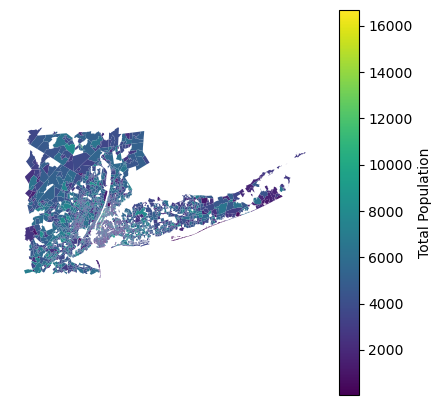

In [192]:
fig, ax = plt.subplots(figsize=(5, 5))
gdf_ny_merged.plot(
    column='pop_total',
    cmap='viridis',
    legend=True,
    legend_kwds={'label': "Total Population"},
    ax=ax
)
ax.axis('off')
plt.show()

In [193]:
gdf_ny_merged['med_gross_rent'].value_counts()

med_gross_rent
3501    164
1750     12
1664     11
1897     11
1602     10
       ... 
3456      1
1487      1
3447      1
1255      1
1232      1
Name: count, Length: 1777, dtype: int64

chicago: 17506 hex cells created
la: 26626 hex cells created
boston: 10445 hex cells created
austin: 16328 hex cells created
nyc: 4837 hex cells created


<Axes: >

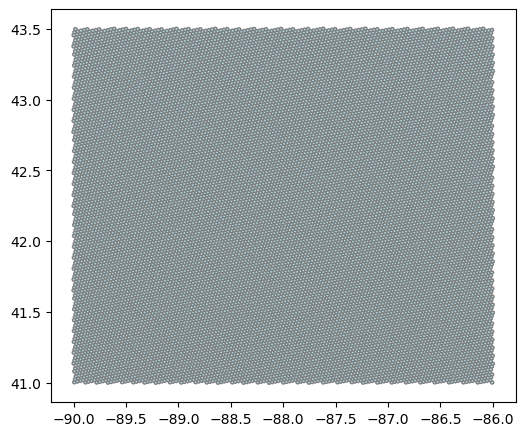

In [194]:
RESOLUTION = 7
all_city_hexes = {}

for city, bbox in bbox_dict.items():
    # Create a rectangular polygon for the bbox
    bbox_poly = Polygon([
        (bbox['lon_min'], bbox['lat_min']),
        (bbox['lon_max'], bbox['lat_min']),
        (bbox['lon_max'], bbox['lat_max']),
        (bbox['lon_min'], bbox['lat_max']),
        (bbox['lon_min'], bbox['lat_min'])
    ])

    # Convert to LatLngPoly for H3
    outer_ring = [[y, x] for x, y in bbox_poly.exterior.coords[:]]
    latlng_poly = h3.LatLngPoly(outer_ring)

    base_cells = h3.polygon_to_cells(latlng_poly, res=RESOLUTION)

    # Convert cells to shapely polygons
    hex_polygons = [
        Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
        for cell in base_cells
    ]

    # Store as GeoDataFrame
    gdf_hex = gpd.GeoDataFrame({'h3_index': list(base_cells), 'geometry': hex_polygons}, crs='EPSG:4326')

    all_city_hexes[city] = gdf_hex

    print(f"{city}: {len(gdf_hex)} hex cells created")

# Example: plot chicago hex cells
all_city_hexes['chicago'].plot(edgecolor='gray', facecolor='lightblue', figsize=(6,6))


In [195]:
def aggregate_tracts_to_hex(
    hex_gdf,
    tracts_gdf,
    sum_cols,
    mean_cols,
    id_col='h3_index',
    tract_id_col='GISJOIN',
    target_crs='EPSG:5070'   # USA contiguous Albers equal-area (good for area calc)
):
    """
    Spatially intersect tracts -> hex cells and aggregate:
      - sum_cols: area-weighted sums
      - mean_cols: population-weighted averages (fallback to area-weighted)
    Returns GeoDataFrame of hex cells (geometry from hex_gdf) in EPSG:4326.
    """
    # defensive copies
    hex_gdf = hex_gdf.copy()
    tracts_gdf = tracts_gdf.copy()

    # set CRS defaults if missing (assume input in EPSG:4326 if undefined)
    if hex_gdf.crs is None:
        hex_gdf.set_crs(epsg=4326, inplace=True)
    if tracts_gdf.crs is None:
        tracts_gdf.set_crs(epsg=4326, inplace=True)

    # reproject both to equal-area projection for area computations
    hex_p = hex_gdf.to_crs(target_crs)
    tracts_p = tracts_gdf.to_crs(target_crs)

    # compute tract area
    tracts_p['tract_area'] = tracts_p.geometry.area

    # ensure expected numeric columns exist in tracts (create zeros/NAs if missing)
    for c in sum_cols:
        if c not in tracts_p.columns:
            tracts_p[c] = 0
    for c in mean_cols:
        if c not in tracts_p.columns:
            tracts_p[c] = pd.NA

    # keep only the columns we need from tracts and hex to avoid _x/_y collisions
    tract_keep = [tract_id_col, 'geometry', 'tract_area'] + [c for c in (sum_cols + mean_cols) if c in tracts_p.columns]
    tracts_p = tracts_p.loc[:, tract_keep]

    hex_keep = [id_col, 'geometry']
    hex_p = hex_p.loc[:, hex_keep]

    # intersection (each row = intersection polygon of tract x hex)
    inter = gpd.overlay(tracts_p, hex_p, how='intersection')

    if inter.empty:
        # nothing intersects: return hex_gdf in original CRS with zero/NaN columns
        out = hex_gdf[[id_col, 'geometry']].copy()
        for c in sum_cols:
            out[c] = 0
        for c in mean_cols:
            out[c] = pd.NA
        return gpd.GeoDataFrame(out, geometry='geometry', crs=hex_gdf.crs)

    # compute intersection area and fraction of the original tract area
    inter['inter_area'] = inter.geometry.area
    inter['tract_frac'] = inter['inter_area'] / inter['tract_area']

    # allocate count-type columns by tract fraction (area-weight)
    for c in sum_cols:
        inter[c + '_alloc'] = inter[c].fillna(0) * inter['tract_frac']

    # allocate population for weighting means (fallback to area fraction if pop missing)
    if 'pop_total' in inter.columns:
        inter['pop_alloc'] = inter['pop_total'].fillna(0) * inter['tract_frac']
    else:
        inter['pop_alloc'] = inter['tract_frac']  # fallback

    # build numerators for mean-type columns:
    # - population-weighted numerator (value * pop_alloc)
    # - area-weighted numerator (value * tract_frac) for fallback
    for c in mean_cols:
        inter[c + '_num_pop'] = inter[c].fillna(0) * inter['pop_alloc']
        inter[c + '_num_area'] = inter[c].fillna(0) * inter['tract_frac']

    # aggregate by hex id
    agg_dict = {}
    # sum the allocated counts
    for c in sum_cols:
        agg_dict[c + '_alloc'] = 'sum'
    # sums needed for mean calcs
    for c in mean_cols:
        agg_dict[c + '_num_pop'] = 'sum'
        agg_dict[c + '_num_area'] = 'sum'
    # keep pop_alloc and tract_frac sums for denominator/fallback
    agg_dict['pop_alloc'] = 'sum'
    agg_dict['tract_frac'] = 'sum'

    grouped = inter.groupby(id_col).agg(agg_dict).reset_index()

    # compute final aggregated columns
    # sum_cols: just the sum of allocated pieces
    for c in sum_cols:
        grouped[c] = grouped[c + '_alloc'].fillna(0)
        grouped.drop(columns=[c + '_alloc'], inplace=True)

    # mean_cols: first try population-weighted average, else area-weighted
    for c in mean_cols:
        # pop-weighted (avoid division by zero)
        pop_denom = grouped['pop_alloc']
        grouped[c] = grouped[c + '_num_pop'] / pop_denom.replace({0: pd.NA})
        # fallback where population denominator is zero -> use area weighted
        zero_mask = pop_denom == 0
        grouped.loc[zero_mask, c] = grouped.loc[zero_mask, c + '_num_area'] / grouped.loc[zero_mask, 'tract_frac'].replace({0: pd.NA})
        # drop the temporary numerator columns
        grouped.drop(columns=[c + '_num_pop', c + '_num_area'], inplace=True)

    # drop helper columns
    grouped.drop(columns=['pop_alloc', 'tract_frac'], inplace=True)

    # merge aggregated attributes back to hex geometries (projected)
    result = hex_p.merge(grouped, on=id_col, how='left')

    # fill sums with zeros where there were no intersecting tracts
    for c in sum_cols:
        if c in result.columns:
            result[c] = result[c].fillna(0)

    # mean columns can remain NaN (no data)
    # convert geometry back to EPSG:4326 for output
    result = result.to_crs(epsg=4326)

    return result


In [258]:

sum_cols = [
    'total_emp','warehousing_emp_tot', 'pop_total','male_total','female_total',
    'white_alone','black_alone','amind_alone','asian_alone','pacislander_alone',
    'other_race_alone','two_or_more_races','in_labor_force','employed_civ', 'pop_share'
]

mean_cols = ['med_hh_income','med_gross_rent','med_home_value']

# Provide dicts mapping city keys to hex grids and tract GeoDataFrames.
# Replace the right-hand values with your actual variables (gdfs).
# e.g. tracts_by_city = {'chicago': gdf_il_merged, 'la': gdf_ca_merged, ...}
hex_by_city = all_city_hexes   # assumed already created earlier
tracts_by_city = {
    'chicago': gdf_il_merged,
    'la': gdf_ca_merged,
    'boston': gdf_ma_merged,
    'austin': gdf_tx_merged,
    'nyc': gdf_ny_merged
}

# Run aggregation for each city
hex_aggregated = {}
for city, hex_gdf in hex_by_city.items():
    print(f"Processing {city} ...")
    tracts = tracts_by_city[city]   # must exist in mapping
    out_hex = aggregate_tracts_to_hex(hex_gdf, tracts, sum_cols, mean_cols, id_col='h3_index')
    hex_aggregated[city] = out_hex[out_hex['pop_total']>0]
    hex_aggregated[city]['pop_share'] = hex_aggregated[city]['pop_total'] / sum(hex_aggregated[city]['pop_total'])
    hex_aggregated[city]['emp_share'] = hex_aggregated[city]['total_emp'] / sum(hex_aggregated[city]['total_emp'])
    hex_aggregated[city]['warehousing_share'] = hex_aggregated[city]['warehousing_emp_tot'] / sum(hex_aggregated[city]['warehousing_emp_tot'])
    hex_aggregated[city]['centroid'] = hex_aggregated[city].geometry.centroid
    print(f" -> {city}: {len(out_hex)} hex rows")


Processing chicago ...


/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

 -> chicago: 17506 hex rows
Processing la ...


/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

 -> la: 26626 hex rows
Processing boston ...


/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

 -> boston: 10445 hex rows
Processing austin ...


/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

 -> austin: 16328 hex rows
Processing nyc ...
 -> nyc: 4837 hex rows


/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/ox/lib/python3.13/site-packages/geopandas/geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [259]:
for name in ['boston', 'la', 'chicago']:
    warehouse_locations = pd.read_csv('flow_df_for_r_' + name + '.csv')['origin'].unique().tolist()
    
    hex_aggregated[name]['num_warehouses'] = 0
    
    for location in warehouse_locations:
        mask = hex_aggregated[name]['h3_index'] == location
        hex_aggregated[name].loc[mask, 'num_warehouses'] += 1


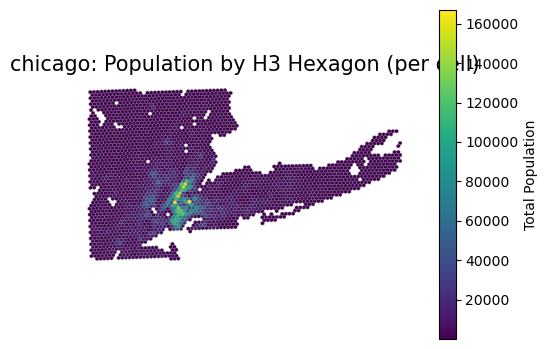

In [260]:

hex_il = hex_aggregated['nyc']

# Plot setup
fig, ax = plt.subplots(figsize=(5, 5))

# Use a colormap to represent population intensity
hex_il[hex_il['pop_total']>0].plot(
    column='pop_total',
    cmap='viridis',
    linewidth=0.2,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': "Total Population", 'shrink': 0.7},
    ax=ax
)

ax.set_title("chicago: Population by H3 Hexagon (per cell)", fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [261]:
nyc_poi = pd.read_csv('../data/poi_hex_nyc.csv')[['h3_index', 'num_warehouses', 'num_express_vendors']]
nyc_poi

,h3_index,num_warehouses,num_express_vendors
0,872a10725ffffff,0,188
1,872a10741ffffff,2,54
2,872a10053ffffff,0,11
3,872a1072bffffff,0,1
4,872a100e5ffffff,0,14
...,...,...,...
297,872a10719ffffff,0,0
298,872a1005dffffff,0,0
299,872a1000effffff,0,0
300,872a1018dffffff,0,0


In [262]:
hex_aggregated['nyc'] = hex_aggregated['nyc'].merge(nyc_poi, on='h3_index', how='inner')
hex_aggregated['nyc']

,h3_index,geometry,total_emp,warehousing_emp_tot,pop_total,male_total,female_total,white_alone,black_alone,amind_alone,...,employed_civ,pop_share,med_hh_income,med_gross_rent,med_home_value,emp_share,warehousing_share,centroid,num_warehouses,num_express_vendors
0,872a10753ffffff,"POLYGON ((-74.07177 40.60404, -74.08644 40.597...",5892.831077,1408.763517,12212.256066,0.0,0.0,0.0,0.0,0.0,...,5892.831077,0.000708,86247.488334,1785.516646,-5.344755e+06,0.000692,0.000697,POINT (-74.07127 40.59174),0,11
1,872a10008ffffff,"POLYGON ((-73.76544 40.81561, -73.78021 40.809...",490.148651,115.441547,1306.630142,0.0,0.0,0.0,0.0,0.0,...,490.148651,0.000076,160616.668062,2987.163499,1.557519e+06,0.000058,0.000057,POINT (-73.76501 40.80328),0,0
2,872a1001effffff,"POLYGON ((-73.8567 40.85033, -73.87147 40.8437...",41906.132098,12257.265215,95761.530362,0.0,0.0,0.0,0.0,0.0,...,41906.132098,0.005548,59331.766824,1705.990282,-3.337428e+07,0.004920,0.006069,POINT (-73.85625 40.83799),0,60
3,872a1004affffff,"POLYGON ((-73.68626 40.68805, -73.701 40.68153...",6807.936398,1418.703220,13522.602175,0.0,0.0,0.0,0.0,0.0,...,6807.936398,0.000783,140564.520419,2323.111040,6.139588e+05,0.000799,0.000702,POINT (-73.68585 40.67574),0,0
4,872a100e3ffffff,"POLYGON ((-73.83836 40.75822, -73.85311 40.751...",11954.008754,3225.123132,26583.920567,0.0,0.0,0.0,0.0,0.0,...,11954.008754,0.001540,62655.253442,1795.829607,7.938504e+05,0.001404,0.001597,POINT (-73.83792 40.7459),0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,872a10708ffffff,"POLYGON ((-74.0748 40.67789, -74.08949 40.6713...",1385.679929,396.607624,2726.465059,0.0,0.0,0.0,0.0,0.0,...,1385.679929,0.000158,118391.256033,2093.282516,4.230927e+05,0.000163,0.000196,POINT (-74.0743 40.66558),0,0
258,872a1018affffff,"POLYGON ((-73.90516 40.94176, -73.91996 40.935...",15870.676910,5157.318890,35459.369429,0.0,0.0,0.0,0.0,0.0,...,15870.676910,0.002054,54895.444364,1527.059062,-2.834348e+08,0.001863,0.002553,POINT (-73.9047 40.92941),0,0
259,872a10015ffffff,"POLYGON ((-73.82803 40.88813, -73.84282 40.881...",18972.296277,3758.816264,44414.842748,0.0,0.0,0.0,0.0,0.0,...,18972.296277,0.002573,67115.840663,1412.708206,2.013894e+05,0.002228,0.001861,POINT (-73.82759 40.87579),0,10
260,872a10760ffffff,"POLYGON ((-73.92397 40.64502, -73.93866 40.638...",26747.844254,6027.663502,56331.550137,0.0,0.0,0.0,0.0,0.0,...,26747.844254,0.003264,86648.039556,1753.302739,-3.630955e+07,0.003141,0.002984,POINT (-73.9235 40.63271),0,3


In [263]:
hex_aggregated['nyc'].columns

Index(['h3_index', 'geometry', 'total_emp', 'warehousing_emp_tot', 'pop_total',
       'male_total', 'female_total', 'white_alone', 'black_alone',
       'amind_alone', 'asian_alone', 'pacislander_alone', 'other_race_alone',
       'two_or_more_races', 'in_labor_force', 'employed_civ', 'pop_share',
       'med_hh_income', 'med_gross_rent', 'med_home_value', 'emp_share',
       'warehousing_share', 'centroid', 'num_warehouses',
       'num_express_vendors'],
      dtype='object')

In [264]:
hex_aggregated['chicago'].to_csv('../data/census_hex_chicago.csv')
hex_aggregated['la'].to_csv('../data/census_hex_la.csv')
hex_aggregated['boston'].to_csv('../data/census_hex_boston.csv')
hex_aggregated['nyc'].to_csv('../data/census_hex_nyc.csv')

In [265]:
hex_aggregated['chicago']

,h3_index,geometry,total_emp,warehousing_emp_tot,pop_total,male_total,female_total,white_alone,black_alone,amind_alone,...,in_labor_force,employed_civ,pop_share,med_hh_income,med_gross_rent,med_home_value,emp_share,warehousing_share,centroid,num_warehouses
0,872666311ffffff,"POLYGON ((-88.52876 41.12257, -88.54109 41.114...",11.769207,5.233472,22.927979,0.0,0.0,0.0,0.0,0.0,...,12.143608,11.769207,2.298949e-06,85750.000000,983.000000,210200.000000,2.365250e-06,2.834188e-06,POINT (-88.52451 41.11058),0
2,872675142ffffff,"POLYGON ((-90.00387 41.14782, -90.01589 41.139...",0.227959,0.082702,0.532259,0.0,0.0,0.0,0.0,0.0,...,0.235381,0.227959,5.336868e-08,59000.000000,771.000000,93800.000000,4.581286e-08,4.478706e-08,POINT (-89.99926 41.13591),0
7,872660dacffffff,"POLYGON ((-88.03618 41.06569, -88.0486 41.0574...",37.444574,15.625830,86.946875,0.0,0.0,0.0,0.0,0.0,...,39.823309,37.444574,8.718015e-06,85682.000000,1090.000000,196900.000000,7.525212e-06,8.462173e-06,POINT (-88.03206 41.05367),0
13,872666983ffffff,"POLYGON ((-88.60192 41.75939, -88.6144 41.7510...",46.899871,12.820630,90.156396,0.0,0.0,0.0,0.0,0.0,...,49.657576,46.899871,9.039828e-06,112421.964000,1480.335817,317894.602016,9.425437e-06,6.943016e-06,POINT (-88.59759 41.74731),0
15,87266406dffffff,"POLYGON ((-87.07912 41.45357, -87.09184 41.445...",696.742651,178.930019,1279.620745,0.0,0.0,0.0,0.0,0.0,...,715.991184,696.742651,1.283054e-04,124479.000000,1119.000000,344100.000000,1.400239e-04,9.689961e-05,POINT (-87.0752 41.44146),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17494,872759044ffffff,"POLYGON ((-88.20455 42.2625, -88.21725 42.2541...",1442.085181,544.683920,2527.441056,0.0,0.0,0.0,0.0,0.0,...,1512.010722,1442.085181,2.534222e-04,98066.313567,1689.844843,263181.928121,2.898149e-04,2.949738e-04,POINT (-88.20027 42.25033),0
17496,872675956ffffff,"POLYGON ((-89.76884 41.49308, -89.781 41.48465...",14.809525,7.690293,29.856992,0.0,0.0,0.0,0.0,0.0,...,15.275892,14.809525,2.993710e-06,71548.000000,750.000000,129800.000000,2.976261e-06,4.164681e-06,POINT (-89.76425 41.4811),0
17498,872664a62ffffff,"POLYGON ((-86.61493 41.44289, -86.62775 41.434...",54.670114,36.641219,123.095158,0.0,0.0,0.0,0.0,0.0,...,57.063308,54.670114,1.234254e-05,72920.590596,769.519792,148360.493104,1.098702e-05,1.984306e-05,POINT (-86.61113 41.43076),0
17499,872666b25ffffff,"POLYGON ((-88.07743 41.49665, -88.08996 41.488...",273.791528,165.495157,625.830996,0.0,0.0,0.0,0.0,0.0,...,296.823572,273.791528,6.275101e-05,65436.000000,1292.000000,164300.000000,5.502371e-05,8.962396e-05,POINT (-88.07326 41.48458),0


In [266]:
hex_aggregated['chicago'].describe()

,total_emp,warehousing_emp_tot,pop_total,male_total,female_total,white_alone,black_alone,amind_alone,asian_alone,pacislander_alone,...,two_or_more_races,in_labor_force,employed_civ,pop_share,med_hh_income,med_gross_rent,med_home_value,emp_share,warehousing_share,num_warehouses
count,7965.000000,7965.000000,7965.000000,7965.0,7965.0,7965.0,7965.0,7965.0,7965.0,7965.0,...,7965.0,7965.000000,7965.000000,7.965000e+03,7965.000000,7965.000000,7.965000e+03,7.965000e+03,7.965000e+03,7965.000000
mean,624.718532,231.833070,1252.133316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,666.713565,624.718532,1.255493e-04,85824.166164,1113.516776,-7.983221e+05,1.255493e-04,1.255493e-04,0.000502
std,2054.206970,652.823840,3780.525564,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2184.738717,2054.206970,3.790669e-04,24484.611603,388.444453,1.781997e+07,4.128326e-04,3.535370e-04,0.022406
min,0.000343,0.000157,0.000730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000353,0.000343,7.323737e-11,22215.000000,388.925484,-6.666667e+08,6.889742e-11,8.500247e-11,0.000000
25%,26.154221,11.873103,53.214525,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,26.949984,26.154221,5.335730e-06,70263.000000,855.000000,1.554000e+05,5.256197e-06,6.429883e-06,0.000000
50%,55.604754,27.087358,116.412417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,57.482118,55.604754,1.167248e-05,83026.000000,1002.914616,1.970399e+05,1.117485e-05,1.466917e-05,0.000000
75%,263.000230,112.873071,543.004622,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,277.576016,263.000230,5.444615e-05,94792.024866,1247.120411,2.591984e+05,5.285499e-05,6.112645e-05,0.000000
max,58303.866875,9656.037516,81853.384467,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,59928.454619,58303.866875,8.207300e-03,250001.000000,3501.000000,1.327174e+06,1.171729e-02,5.229230e-03,1.000000


In [267]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    lat1, lat2 = radians(lat1), radians(lat2)
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

In [268]:
empty_od = pd.MultiIndex.from_product(
    [hex_aggregated['nyc']['h3_index'], hex_aggregated['nyc']['h3_index']],
    names=["origin", "destination"]
).to_frame(index=False)

empty_od = empty_od.merge(hex_aggregated['nyc'][['h3_index', 'centroid']].rename(columns={"h3_index": "origin", "centroid": "origin_cent"}),
              on="origin", how="left")

empty_od = empty_od.merge(hex_aggregated['nyc'][['h3_index', 'centroid']].rename(columns={"h3_index": "destination", "centroid": "dest_cent"}),
              on="destination", how="left")

empty_od["distance_km"] = empty_od.apply(
    lambda row: haversine(
        row.origin_cent.y, row.origin_cent.x,  # lat1, lon1
        row.dest_cent.y, row.dest_cent.x       # lat2, lon2
    ),
    axis=1
)

empty_od


,origin,destination,origin_cent,dest_cent,distance_km
0,872a10753ffffff,872a10753ffffff,POINT (-74.07127 40.59174),POINT (-74.07127 40.59174),0.000000
1,872a10753ffffff,872a10008ffffff,POINT (-74.07127 40.59174),POINT (-73.76501 40.80328),34.926798
2,872a10753ffffff,872a1001effffff,POINT (-74.07127 40.59174),POINT (-73.85625 40.83799),32.835871
3,872a10753ffffff,872a1004affffff,POINT (-74.07127 40.59174),POINT (-73.68585 40.67574),33.837817
4,872a10753ffffff,872a100e3ffffff,POINT (-74.07127 40.59174),POINT (-73.83792 40.7459),26.098978
...,...,...,...,...,...
68639,872a10776ffffff,872a10708ffffff,POINT (-74.01454 40.66722),POINT (-74.0743 40.66558),5.043450
68640,872a10776ffffff,872a1018affffff,POINT (-74.01454 40.66722),POINT (-73.9047 40.92941),30.584805
68641,872a10776ffffff,872a10015ffffff,POINT (-74.01454 40.66722),POINT (-73.82759 40.87579),28.029861
68642,872a10776ffffff,872a10760ffffff,POINT (-74.01454 40.66722),POINT (-73.9235 40.63271),8.585620


In [269]:
empty_od.to_csv('../data/empty_od_nyc.csv')

# **DUBAI DATA**

In [246]:
dubai_census_hex = pd.read_csv('../data/dubai_pop_merged.csv')
print(dubai_census_hex.head())

   Unnamed: 0         h3_index  \
0           0  8743a1273ffffff   
1           1  8743ac50cffffff   
2           2  8743a1262ffffff   
3           3  8743a1303ffffff   
4           4  8743a1231ffffff   

                                            geometry        vendor_h3  \
0  POLYGON ((6162854.925473966 2883963.557794797,...  8743a1273ffffff   
1  POLYGON ((6185540.8866457045 2899533.866060492...              NaN   
2  POLYGON ((6162037.263047185 2888956.7737859585...  8743a1262ffffff   
3  POLYGON ((6137797.576727251 2883361.6756042023...  8743a1303ffffff   
4  POLYGON ((6148067.737760672 2876561.645343562,...  8743a1231ffffff   

   num_vendors      customer_h3  num_customers  \
0            1  8743a1273ffffff              4   
1            0  8743ac50cffffff             10   
2           52  8743a1262ffffff           1135   
3          131  8743a1303ffffff           1111   
4            8  8743a1231ffffff            387   

                                       centroid     pop

In [247]:
dubai_rent = pd.read_csv('../data/units_for_rent_oct2023.csv')
print(dubai_rent.head())

        type                                               name  \
0      House  Corner Villa | Type A | Move In Ready | Call Now!   
1      House  TYPE 4E/2BED+MAID/CLOSE TO LAKE/BIGGER PLOT  2...   
2      House        Corner Unit | Vacant | Brand New | Spacious   
3  Apartment         1 Bedroom Apartment | Upgraded | Pool View   
4  Apartment       Park View I Available Now I With Maid's Room   

                                                 url   latitude  longitude  \
0  https://www.bayut.com/property/details-8040160...  25.013264  55.300633   
1  https://www.bayut.com/property/details-7783559...  25.058849  55.185664   
2  https://www.bayut.com/property/details-8046109...  25.062192  55.323659   
3  https://www.bayut.com/property/details-7999688...  25.091045  55.173639   
4  https://www.bayut.com/property/details-7923202...  25.069335  55.245798   

  floorsize floorsize_unit  num_baths    price  SELECTED_1  SELECTED_2  \
0     3,222           SQFT          4  155,000        

In [248]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point

# ---------------------------
# 0) Remove outlier rents (1st and 99th percentile)
# ---------------------------

# Convert price to numeric first
dubai_rent['price'] = dubai_rent['price'].astype(str).str.replace(',', '').astype(float)

# Compute 1st and 99th percentiles
p1 = dubai_rent['price'].quantile(0.01)
p99 = dubai_rent['price'].quantile(0.99)

# Keep only rents within 1st-99th percentile
dubai_rent_filtered = dubai_rent[(dubai_rent['price'] >= p1) & (dubai_rent['price'] <= p99)]

# ---------------------------
# 1) Convert dubai_census_hex to GeoDataFrame
# ---------------------------

# Convert WKT strings to Shapely Polygons
dubai_census_hex['geometry'] = dubai_census_hex['geometry'].apply(wkt.loads)

# Convert to GeoDataFrame
hex_gdf = gpd.GeoDataFrame(
    dubai_census_hex,
    geometry='geometry',
    crs="EPSG:3857"  # set CRS to match your projected coordinates
)

# ---------------------------
# 2) Convert rental units to GeoDataFrame
# ---------------------------

rent_gdf = gpd.GeoDataFrame(
    dubai_rent_filtered,
    geometry=gpd.points_from_xy(dubai_rent_filtered.longitude, dubai_rent_filtered.latitude),
    crs="EPSG:4326"  # lat/lon CRS
)

# Reproject rental points to same CRS as hexes
rent_gdf = rent_gdf.to_crs(hex_gdf.crs)

# ---------------------------
# 3) Spatial join: assign each rental to the hex it falls in
# ---------------------------

joined = gpd.sjoin(
    rent_gdf,
    hex_gdf[['h3_index', 'geometry']],
    how='inner',
    predicate='within'
)

# ---------------------------
# 4) Compute mean rent and rental counts per hex
# ---------------------------

hex_stats = joined.groupby('h3_index')['price'].agg(['mean', 'count']).reset_index()
hex_stats = hex_stats.rename(columns={'mean': 'mean_rent', 'count': 'num_rentals'})

# ---------------------------
# 5) Merge mean_rent into hex GeoDataFrame
# ---------------------------

hex_gdf = hex_gdf.merge(hex_stats[['h3_index', 'mean_rent', 'num_rentals']], on='h3_index', how='left')

# Compute overall mean rent for the city (used for empty or single-unit cells)
overall_mean_rent = hex_gdf.loc[hex_gdf['num_rentals'] > 1, 'mean_rent'].mean()

# Replace NaN or cells with 0 or 1 rentals with overall mean
hex_gdf['mean_rent'] = hex_gdf.apply(
    lambda row: overall_mean_rent if pd.isna(row['mean_rent']) or row['num_rentals'] <= 1 else row['mean_rent'],
    axis=1
)

# Optional: drop the temporary num_rentals column
hex_gdf = hex_gdf.drop(columns=['num_rentals'])

# ---------------------------
# 6) Inspect results
# ---------------------------

print(hex_gdf[['h3_index', 'num_vendors', 'num_customers', 'mean_rent']].head())


          h3_index  num_vendors  num_customers      mean_rent
0  8743a1273ffffff            1              4  190027.852466
1  8743ac50cffffff            0             10  190027.852466
2  8743a1262ffffff           52           1135   48279.601604
3  8743a1303ffffff          131           1111  329895.869333
4  8743a1231ffffff            8            387   74877.387755


<Axes: >

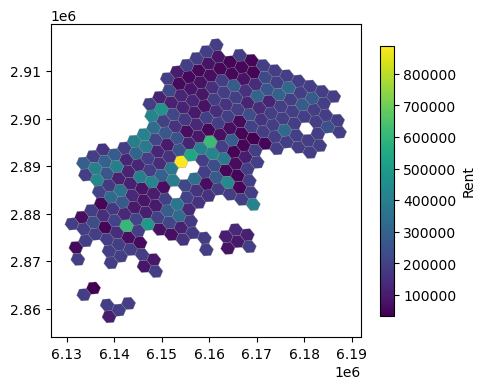

In [249]:
fig, ax = plt.subplots(figsize=(5, 5))

hex_gdf.plot(
    column='mean_rent',
    cmap='viridis',
    linewidth=0.2,
    edgecolor='grey',
    legend=True,
    legend_kwds={'label': "Rent", 'shrink': 0.7},
    ax=ax
)

In [250]:
hex_gdf.to_csv('../data/census_hex_dubai.csv')
